In [ ]:
                                 Aircraft Performance Analysis Using Python


In [2]:
import pandas as pd
df=pd.read_csv('/Users/Malavika/Downloads/Aiplane_BlueBook.csv.xls')
df.index

RangeIndex(start=0, stop=861, step=1)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Model                    861 non-null    object 
 1   Company                  861 non-null    object 
 2   Engine Type              834 non-null    object 
 3   HP or lbs thr ea engine  834 non-null    object 
 4   Max speed Knots          791 non-null    object 
 5   Rcmnd cruise Knots       811 non-null    object 
 6   Stall Knots dirty        735 non-null    object 
 7   Fuel gal/lbs             807 non-null    float64
 8   All eng service ceiling  780 non-null    float64
 9   Eng out service ceiling  332 non-null    object 
 10  All eng rate of climb    752 non-null    object 
 11  Eng out rate of climb    358 non-null    object 
 12  Takeoff over 50ft        712 non-null    float64
 13  Takeoff ground run       691 non-null    float64
 14  Landing over 50ft        7

In [4]:
df.head()

,Model,Company,Engine Type,HP or lbs thr ea engine,Max speed Knots,Rcmnd cruise Knots,Stall Knots dirty,Fuel gal/lbs,All eng service ceiling,Eng out service ceiling,...,Takeoff over 50ft,Takeoff ground run,Landing over 50ft,Landing ground roll,Gross weight lbs,Empty weight lbs,Length ft/in,Height ft/in,Wing span ft/in,Range N.M.
0,15 AC Sedan,Aeronca,Piston,145,104,91,46,36.0,13000.0,NaN,...,900.0,NaN,1300.0,NaN,2050,1180,25/3,10/3,37/5,370
1,11 CC Super Chief,Aeronca,Piston,85,89,83,44,15.0,12300.0,NaN,...,720.0,NaN,800.0,NaN,1350,820,20/7,8/9,36/1,190
2,7 CCM Champ,Aeronca,Piston,90,90,78,37,19.0,16000.0,NaN,...,475.0,NaN,850.0,NaN,1300,810,21/5,8/7,35/0,210
3,7 DC Champ,Aeronca,Piston,85,88,78,37,19.0,13000.0,NaN,...,500.0,NaN,850.0,NaN,1300,800,21/5,8/7,35/0,210
4,7 AC Champ,Aeronca,Piston,65,83,74,33,14.0,12500.0,NaN,...,632.0,NaN,885.0,NaN,1220,740,21/5,8/9,35/0,175


In [5]:
df.isnull().sum()

Model                        0
Company                      0
Engine Type                 27
HP or lbs thr ea engine     27
Max speed Knots             70
Rcmnd cruise Knots          50
Stall Knots dirty          126
Fuel gal/lbs                54
All eng service ceiling     81
Eng out service ceiling    529
All eng rate of climb      109
Eng out rate of climb      503
Takeoff over 50ft          149
Takeoff ground run         170
Landing over 50ft          149
Landing ground roll        201
Gross weight lbs            31
Empty weight lbs            27
Length ft/in                39
Height ft/in                42
Wing span ft/in             29
Range N.M.                 103
dtype: int64

In [6]:
df.drop(columns=["HP or lbs thr ea engine","Stall Knots dirty","Eng out service ceiling","Eng out rate of climb","Length ft/in","Height ft/in","Wing span ft/in"],inplace=True)
df.shape

(861, 15)

In [7]:
df.rename(columns={
    "Model": "Aircraft Model",
    "Company": "Manufacturer",
    "Max speed Knots":"Max speed",
    "Rcmnd cruise Knots":"Cruise speed",
    "Fuel gal/lbs":"Fuel capacity",
    "All eng service ceiling":"Service ceiling",
    "All eng rate of climb":"Climb rate",
    "Takeoff over 50ft":"Takeoff distance",
    "Takeoff ground run":"Takeoff Run",
    "Landing over 50ft":"Landing Distance",
    "Landing ground roll":"Landing Run",
    "Gross weight lbs":"Gross Weight",
    "Empty weight lbs":"Empty Weight",
    "Range N.M.":"Aircraft Range",
},inplace=True)


In [8]:
df.head()

,Aircraft Model,Manufacturer,Engine Type,Max speed,Cruise speed,Fuel capacity,Service ceiling,Climb rate,Takeoff distance,Takeoff Run,Landing Distance,Landing Run,Gross Weight,Empty Weight,Aircraft Range
0,15 AC Sedan,Aeronca,Piston,104,91,36.0,13000.0,450,900.0,NaN,1300.0,NaN,2050,1180,370
1,11 CC Super Chief,Aeronca,Piston,89,83,15.0,12300.0,600,720.0,NaN,800.0,NaN,1350,820,190
2,7 CCM Champ,Aeronca,Piston,90,78,19.0,16000.0,650,475.0,NaN,850.0,NaN,1300,810,210
3,7 DC Champ,Aeronca,Piston,88,78,19.0,13000.0,620,500.0,NaN,850.0,NaN,1300,800,210
4,7 AC Champ,Aeronca,Piston,83,74,14.0,12500.0,370,632.0,NaN,885.0,NaN,1220,740,175


In [9]:
df.isnull().sum()

Aircraft Model        0
Manufacturer          0
Engine Type          27
Max speed            70
Cruise speed         50
Fuel capacity        54
Service ceiling      81
Climb rate          109
Takeoff distance    149
Takeoff Run         170
Landing Distance    149
Landing Run         201
Gross Weight         31
Empty Weight         27
Aircraft Range      103
dtype: int64

In [10]:
df["Engine Type"].unique()

array(['Piston', 'Propjet', 'Jet', 'piston', 'Pistion', 'TSIO 520',
       'IO550', 'PT6A-35', 'PT6A-21', nan], dtype=object)

In [11]:
df["Engine Type"] = df["Engine Type"].replace({ "piston": "Piston", "Pistion": "Piston"})
df["Engine Type"].unique()

array(['Piston', 'Propjet', 'Jet', 'TSIO 520', 'IO550', 'PT6A-35',
       'PT6A-21', nan], dtype=object)

In [12]:
df["Engine Type"].mode()

0    Piston
Name: Engine Type, dtype: object

In [13]:
df["Engine Type"]=df["Engine Type"].fillna(df["Engine Type"].mode()[0])
df.isnull().sum()

Aircraft Model        0
Manufacturer          0
Engine Type           0
Max speed            70
Cruise speed         50
Fuel capacity        54
Service ceiling      81
Climb rate          109
Takeoff distance    149
Takeoff Run         170
Landing Distance    149
Landing Run         201
Gross Weight         31
Empty Weight         27
Aircraft Range      103
dtype: int64

In [ ]:
df.dtypes

In [14]:
num_cols = ["Max speed","Cruise speed","Climb rate","Gross Weight","Empty Weight","Aircraft Range"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
df.dtypes

Aircraft Model       object
Manufacturer         object
Engine Type          object
Max speed           float64
Cruise speed        float64
Fuel capacity       float64
Service ceiling     float64
Climb rate          float64
Takeoff distance    float64
Takeoff Run         float64
Landing Distance    float64
Landing Run         float64
Gross Weight        float64
Empty Weight        float64
Aircraft Range      float64
dtype: object

In [15]:
numeric_df = df.select_dtypes(include="number")
numeric_df

,Max speed,Cruise speed,Fuel capacity,Service ceiling,Climb rate,Takeoff distance,Takeoff Run,Landing Distance,Landing Run,Gross Weight,Empty Weight,Aircraft Range
0,104.0,91.0,36.0,13000.0,450.0,900.0,NaN,1300.0,NaN,2050.0,1180.0,370.0
1,89.0,83.0,15.0,12300.0,600.0,720.0,NaN,800.0,NaN,1350.0,820.0,190.0
2,90.0,78.0,19.0,16000.0,650.0,475.0,NaN,850.0,NaN,1300.0,810.0,210.0
3,88.0,78.0,19.0,13000.0,620.0,500.0,NaN,850.0,NaN,1300.0,800.0,210.0
4,83.0,74.0,14.0,12500.0,370.0,632.0,NaN,885.0,NaN,1220.0,740.0,175.0
...,...,...,...,...,...,...,...,...,...,...,...,...
856,198.0,190.0,156.0,22500.0,1400.0,1210.0,970.0,1150.0,865.0,6250.0,4255.0,957.0
857,190.0,178.0,156.0,22500.0,1400.0,1250.0,1000.0,1350.0,950.0,6000.0,3850.0,957.0
858,183.0,171.0,150.0,24000.0,1700.0,1100.0,950.0,1050.0,900.0,5500.0,3800.0,1000.0
859,130.0,116.0,33.0,22000.0,1310.0,NaN,NaN,NaN,NaN,1817.0,1175.0,365.0


In [73]:
numeric_df.corr()

,Max speed,Cruise speed,Fuel capacity,Service ceiling,Climb rate,Takeoff distance,Takeoff Run,Landing Distance,Landing Run,Gross Weight,Empty Weight,Aircraft Range
Max speed,1.000000,0.991735,0.678109,0.894694,0.902489,0.861657,0.452367,0.824562,0.709203,0.764772,0.778102,0.789676
Cruise speed,0.991735,1.000000,0.660008,0.909561,0.899352,0.847674,0.839964,0.817603,0.743287,0.717803,0.714817,0.786370
Fuel capacity,0.678109,0.660008,1.000000,0.631657,0.410190,0.750853,0.540894,0.561575,0.628957,0.977221,0.973783,0.547284
Service ceiling,0.894694,0.909561,0.631657,1.000000,0.834914,0.789833,0.562244,0.789741,0.815122,0.683830,0.690580,0.415683
Climb rate,0.902489,0.899352,0.410190,0.834914,1.000000,0.739270,0.351201,0.720244,0.630665,0.478733,0.470629,0.514932
Takeoff distance,0.861657,0.847674,0.750853,0.789833,0.739270,1.000000,0.922854,0.834085,0.669618,0.795294,0.792879,0.777938
Takeoff Run,0.452367,0.839964,0.540894,0.562244,0.351201,0.922854,1.000000,0.725045,0.567918,0.570750,0.578921,0.303167
Landing Distance,0.824562,0.817603,0.561575,0.789741,0.720244,0.834085,0.725045,1.000000,0.811998,0.672838,0.685760,0.722640
Landing Run,0.709203,0.743287,0.628957,0.815122,0.630665,0.669618,0.567918,0.811998,1.000000,0.685695,0.709603,0.385342
Gross Weight,0.764772,0.717803,0.977221,0.683830,0.478733,0.795294,0.570750,0.672838,0.685695,1.000000,0.996109,0.555502


In [17]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42)

numeric_df_imputed = imputer.fit_transform(numeric_df)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [18]:
numeric_df_imputed = pd.DataFrame(
    numeric_df_imputed,
    columns=numeric_df.columns,
    index=numeric_df.index
)

In [19]:
numeric_df_imputed.isnull().sum()

Max speed           0
Cruise speed        0
Fuel capacity       0
Service ceiling     0
Climb rate          0
Takeoff distance    0
Takeoff Run         0
Landing Distance    0
Landing Run         0
Gross Weight        0
Empty Weight        0
Aircraft Range      0
dtype: int64

In [20]:
numeric_df = df.select_dtypes(include="number")

imputer = IterativeImputer(random_state=42)

numeric_df_imputed = imputer.fit_transform(numeric_df)

numeric_df_imputed = pd.DataFrame(
    numeric_df_imputed,
    columns=numeric_df.columns,
    index=numeric_df.index
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [21]:
df[numeric_df.columns] = numeric_df_imputed
df

,Aircraft Model,Manufacturer,Engine Type,Max speed,Cruise speed,Fuel capacity,Service ceiling,Climb rate,Takeoff distance,Takeoff Run,Landing Distance,Landing Run,Gross Weight,Empty Weight,Aircraft Range
0,15 AC Sedan,Aeronca,Piston,104.0,91.0,36.0,13000.0,450.0,900.000000,281.192207,1300.000000,702.332725,2050.0,1180.0,370.0
1,11 CC Super Chief,Aeronca,Piston,89.0,83.0,15.0,12300.0,600.0,720.000000,214.808573,800.000000,390.518519,1350.0,820.0,190.0
2,7 CCM Champ,Aeronca,Piston,90.0,78.0,19.0,16000.0,650.0,475.000000,-18.862307,850.000000,471.917315,1300.0,810.0,210.0
3,7 DC Champ,Aeronca,Piston,88.0,78.0,19.0,13000.0,620.0,500.000000,-0.714234,850.000000,457.247882,1300.0,800.0,210.0
4,7 AC Champ,Aeronca,Piston,83.0,74.0,14.0,12500.0,370.0,632.000000,92.673114,885.000000,461.121910,1220.0,740.0,175.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,500 A,Twin Commander A/C,Piston,198.0,190.0,156.0,22500.0,1400.0,1210.000000,970.000000,1150.000000,865.000000,6250.0,4255.0,957.0
857,500,Twin Commander A/C,Piston,190.0,178.0,156.0,22500.0,1400.0,1250.000000,1000.000000,1350.000000,950.000000,6000.0,3850.0,957.0
858,520,Twin Commander A/C,Piston,183.0,171.0,150.0,24000.0,1700.0,1100.000000,950.000000,1050.000000,900.000000,5500.0,3800.0,1000.0
859,2180,Varga,Piston,130.0,116.0,33.0,22000.0,1310.0,1573.509065,1018.223826,1405.663127,749.980828,1817.0,1175.0,365.0


<Axes: xlabel='Max speed'>

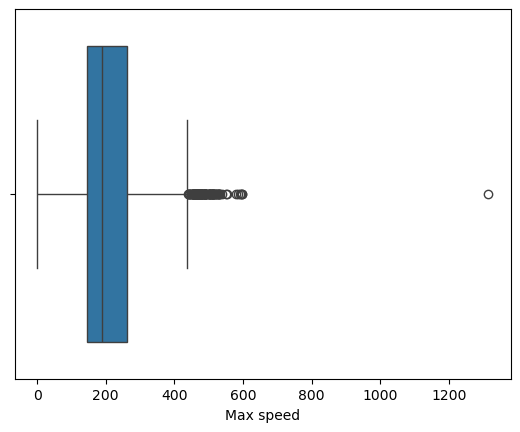

In [22]:
import seaborn as sns
sns.boxplot(x="Max speed",data=df)

<Axes: xlabel='Max speed', ylabel='Count'>

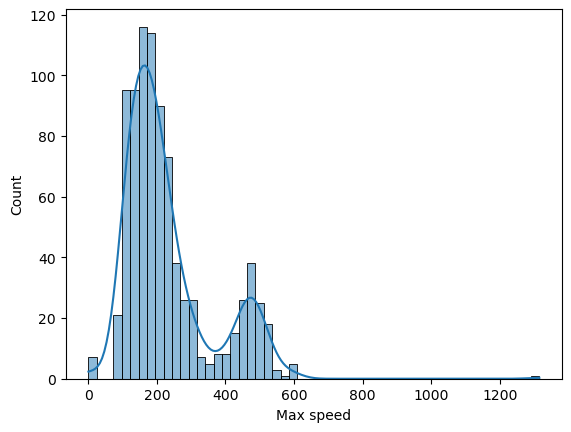

In [23]:
sns.histplot(x="Max speed",data=df,kde=True)

In [24]:
import numpy as np
def replace_outliers(dataframe,feature):
    q1=dataframe[feature].quantile(0.25)
    q3=dataframe[feature].quantile(0.75)
    iqr=q3-q1
    l=q1-1.5*iqr
    u=q3+1.5*iqr

    dataframe[feature]=np.where(dataframe[feature]<l,l,dataframe[feature])
    dataframe[feature]=np.where(dataframe[feature]>u,u,dataframe[feature])

In [25]:
replace_outliers(df,"Max speed")

<Axes: xlabel='Cruise speed'>

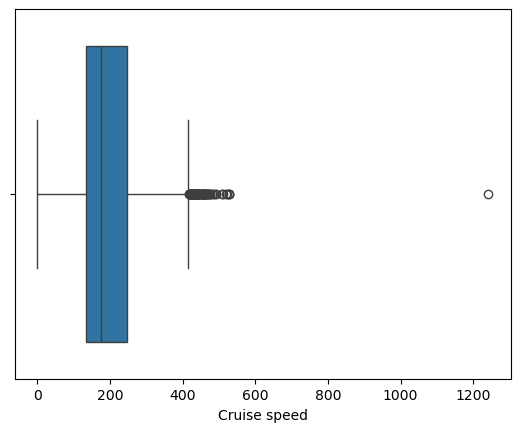

In [26]:
sns.boxplot(x="Cruise speed",data=df)

<Axes: xlabel='Cruise speed', ylabel='Count'>

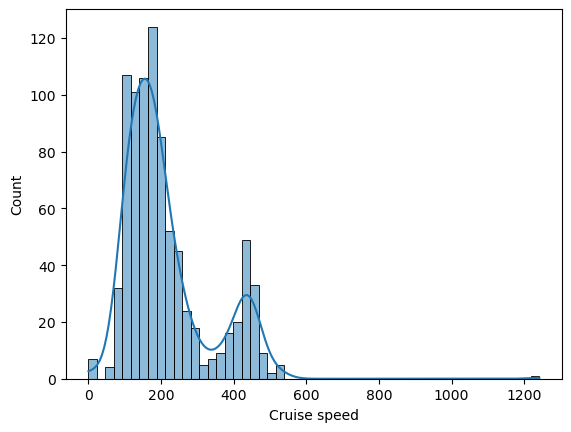

In [27]:
sns.histplot(x="Cruise speed", data=df, kde=True)

In [28]:
replace_outliers(df,"Cruise speed")

<Axes: xlabel='Fuel capacity'>

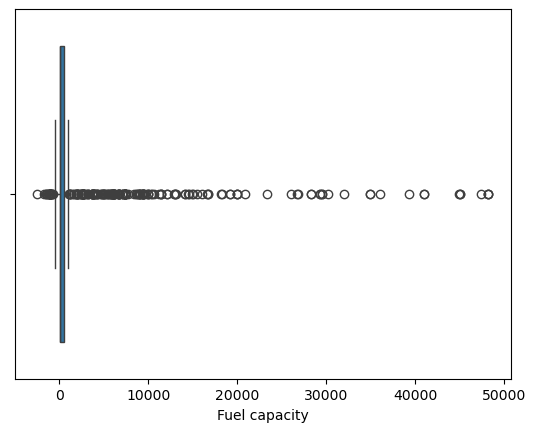

In [29]:
sns.boxplot(x="Fuel capacity",data=df)

<Axes: xlabel='Fuel capacity', ylabel='Count'>

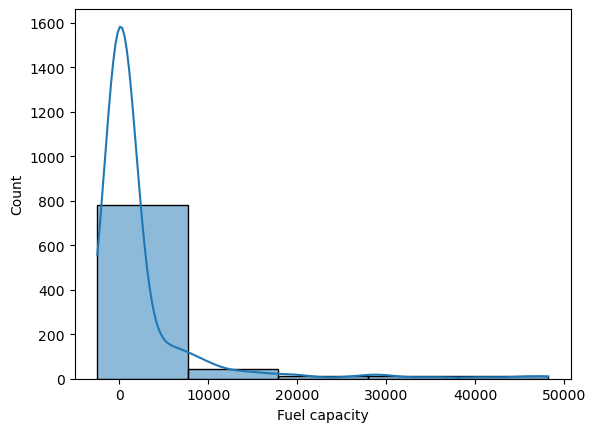

In [30]:
sns.histplot(x="Fuel capacity",data=df,bins=5,kde=True)

In [31]:
replace_outliers(df,"Cruise speed")

<Axes: xlabel='Climb rate'>

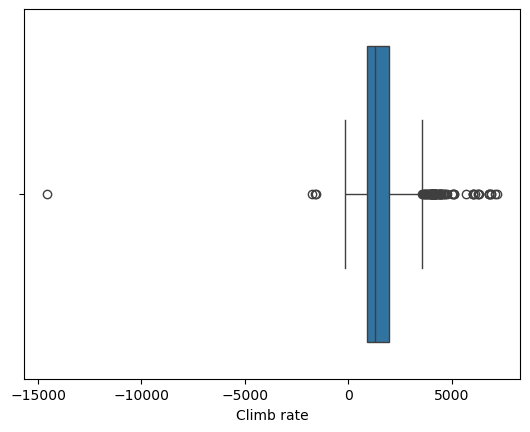

In [32]:
sns.boxplot(x="Climb rate",data=df)

<Axes: xlabel='Climb rate', ylabel='Count'>

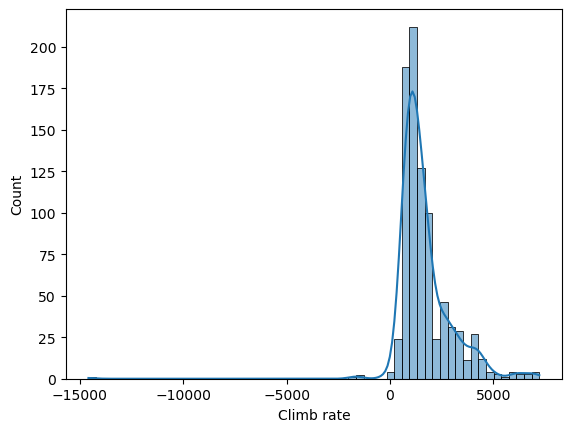

In [33]:
sns.histplot(x="Climb rate",data=df,kde=True)

In [34]:
replace_outliers(df,"Climb rate")

<Axes: xlabel='Takeoff distance'>

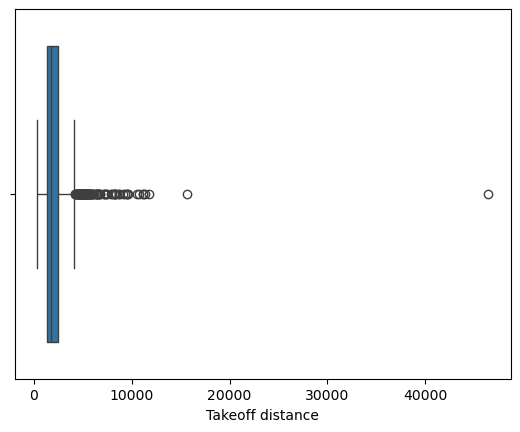

In [35]:
sns.boxplot(x="Takeoff distance",data=df)

<Axes: xlabel='Takeoff distance', ylabel='Count'>

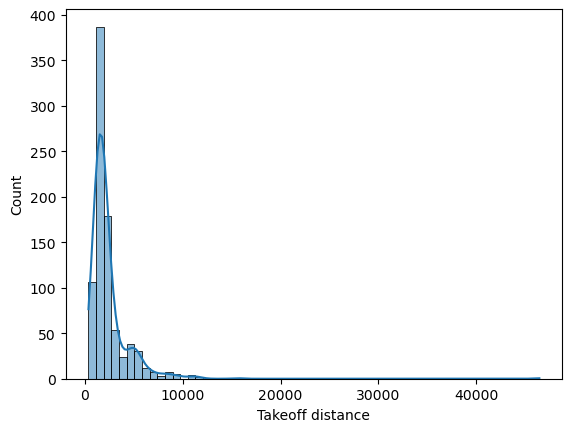

In [36]:
sns.histplot(x="Takeoff distance",data=df,kde=True)

In [37]:
replace_outliers(df,"Takeoff distance")

<Axes: xlabel='Takeoff Run'>

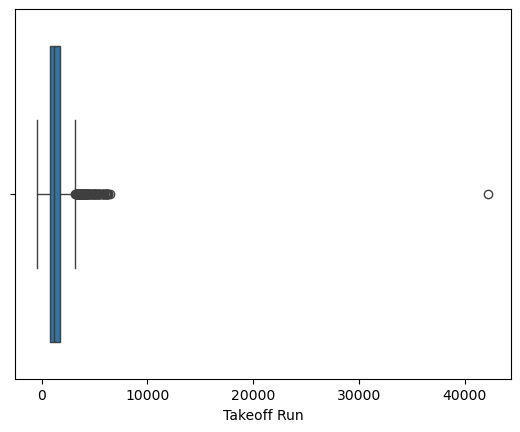

In [38]:
sns.boxplot(x="Takeoff Run",data=df)

<Axes: xlabel='Takeoff Run', ylabel='Count'>

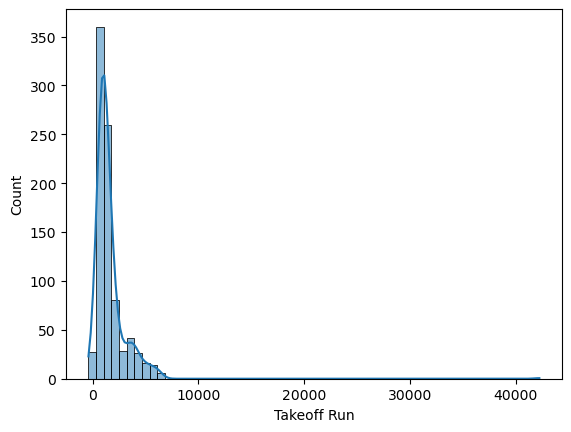

In [39]:
sns.histplot(x="Takeoff Run",data=df,kde=True)

In [40]:
replace_outliers(df,"Takeoff Run")

<Axes: xlabel='Landing Distance'>

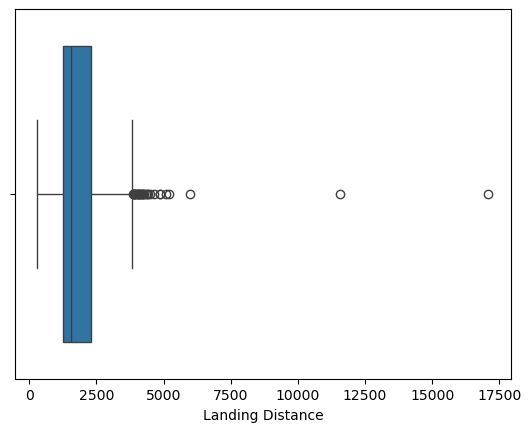

In [41]:
sns.boxplot(x="Landing Distance",data=df)

<Axes: xlabel='Landing Distance', ylabel='Count'>

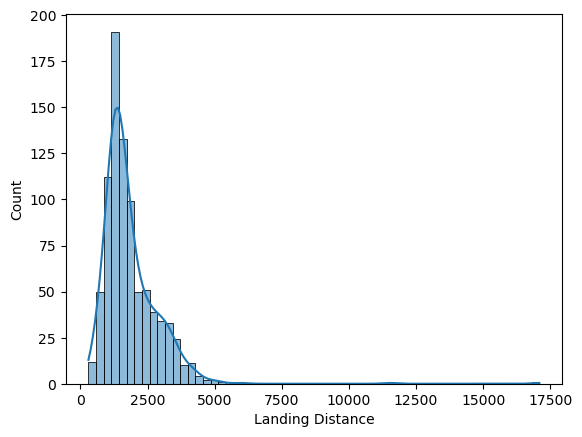

In [42]:
sns.histplot(x="Landing Distance",data=df,kde=True)

In [43]:
replace_outliers(df,"Landing Run")

<Axes: xlabel='Gross Weight'>

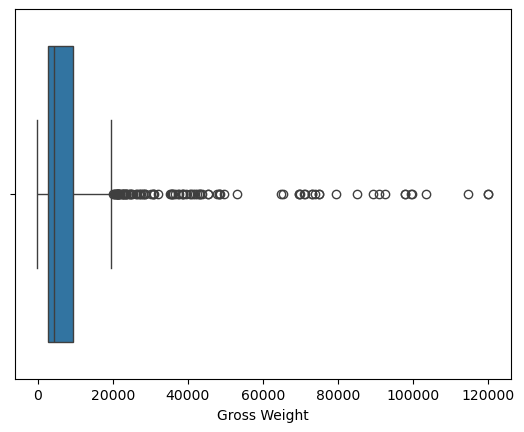

In [44]:
sns.boxplot(x="Gross Weight",data=df)

<Axes: xlabel='Gross Weight', ylabel='Count'>

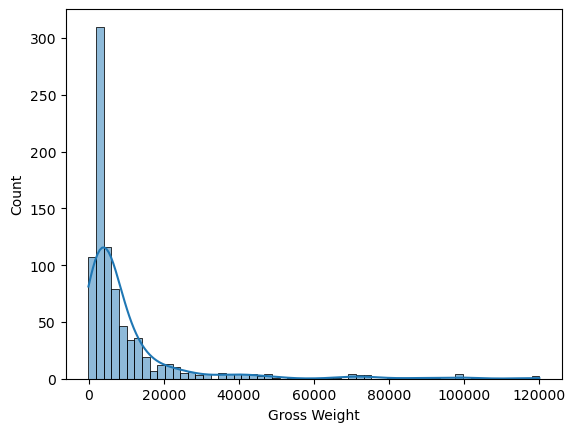

In [45]:
sns.histplot(x="Gross Weight",data=df,kde=True)

In [46]:
replace_outliers(df,"Gross Weight")

<Axes: xlabel='Empty Weight'>

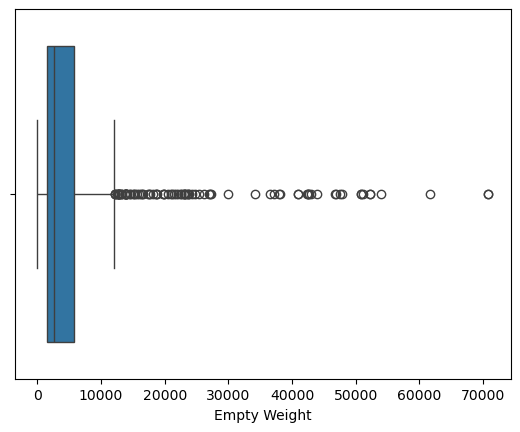

In [47]:
sns.boxplot(x="Empty Weight",data=df)

<Axes: xlabel='Empty Weight', ylabel='Count'>

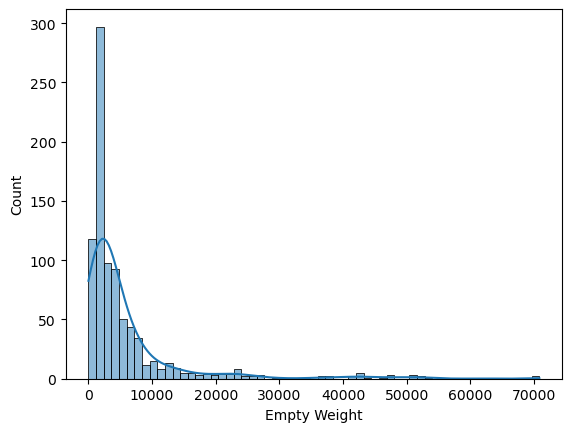

In [48]:
sns.histplot(x="Empty Weight",data=df,kde=True)

In [49]:
replace_outliers(df,"Empty Weight")

<Axes: xlabel='Aircraft Range'>

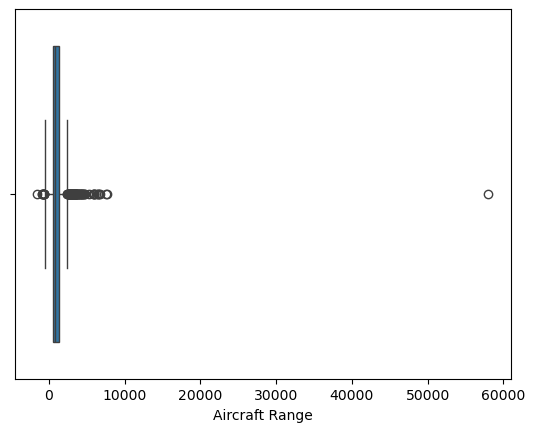

In [50]:
sns.boxplot(x="Aircraft Range",data=df)

<Axes: xlabel='Aircraft Range', ylabel='Count'>

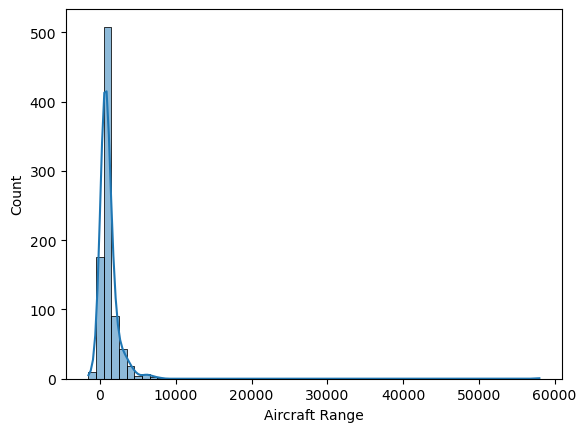

In [51]:
sns.histplot(x="Aircraft Range",data=df,kde=True)

In [52]:
replace_outliers(df,"Aircraft Range")

In [53]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
colors = ["#DCE6E9", "#C1D0D5", "#A6BAC1", "#8BA4AD",
          "#708E99", "#5B7F8A", "#3F6875"]


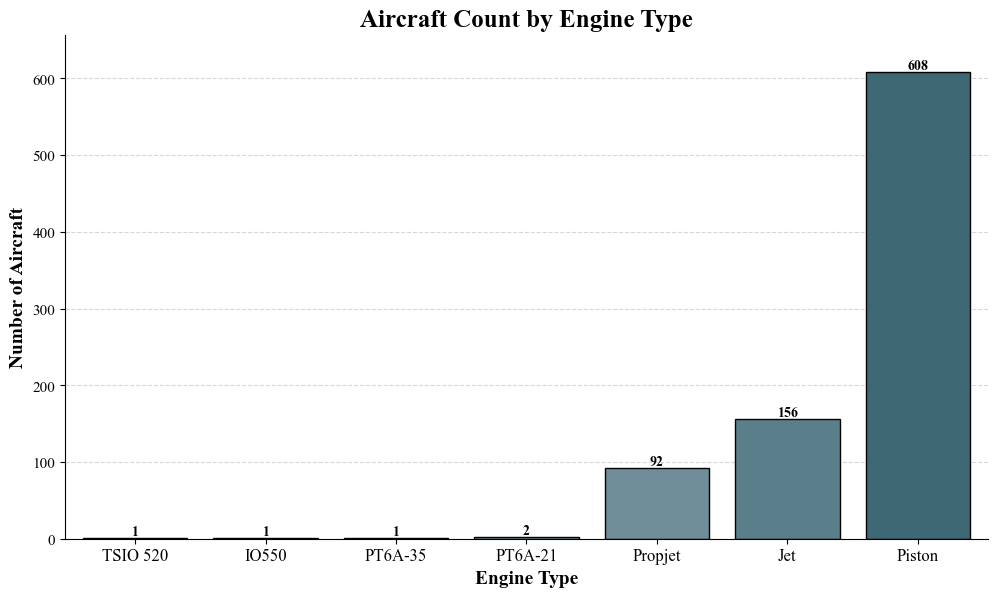

In [82]:
visual_1 = df["Engine Type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_1.index, visual_1.values,
              color=colors[:len(visual_1)], edgecolor="black")

ax.set_title("Aircraft Count by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Aircraft", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_1.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_1.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

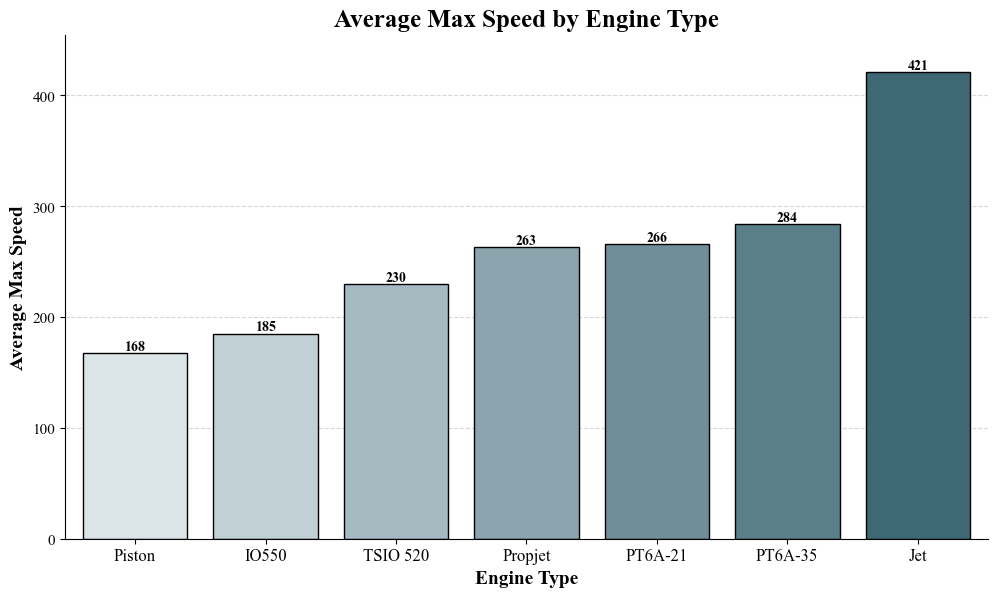

In [83]:
visual_2 = df.groupby("Engine Type")["Max speed"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_2.index, visual_2.values,
              color=colors[:len(visual_2)], edgecolor="black")

ax.set_title("Average Max Speed by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Max Speed", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_2.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_2.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

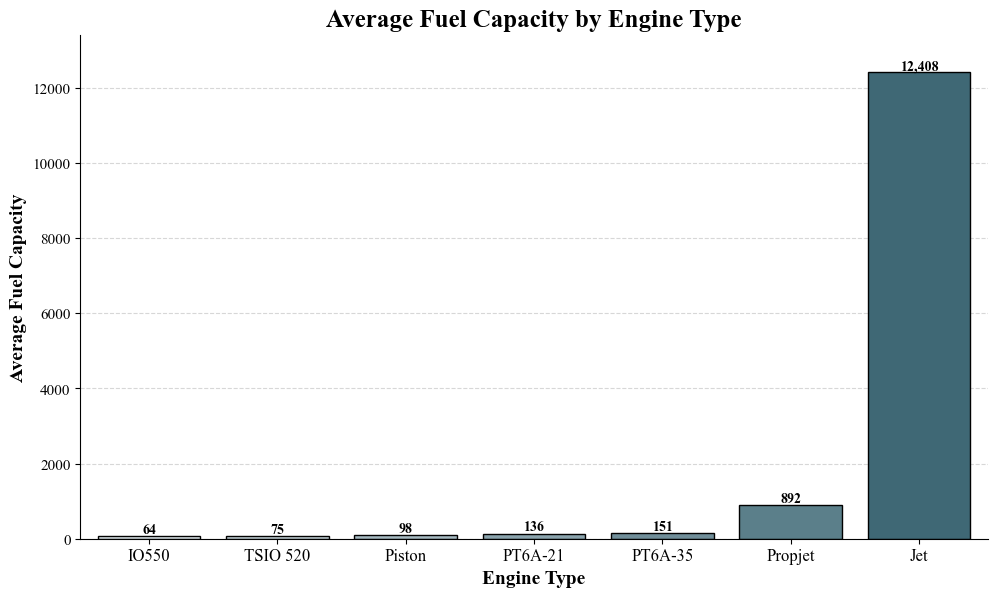

In [84]:
visual_3 = df.groupby("Engine Type")["Fuel capacity"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_3.index, visual_3.values,
              color=colors[:len(visual_3)], edgecolor="black")

ax.set_title("Average Fuel Capacity by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Fuel Capacity", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_3.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_3.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

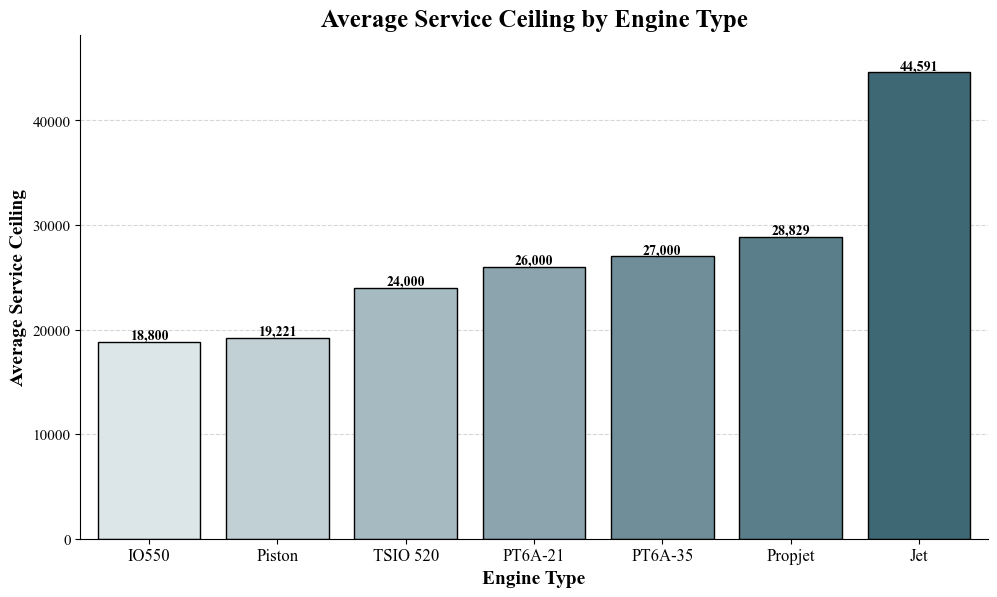

In [85]:
visual_4 = df.groupby("Engine Type")["Service ceiling"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_4.index, visual_4.values,
              color=colors[:len(visual_4)], edgecolor="black")

ax.set_title("Average Service Ceiling by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Service Ceiling", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_4.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_4.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

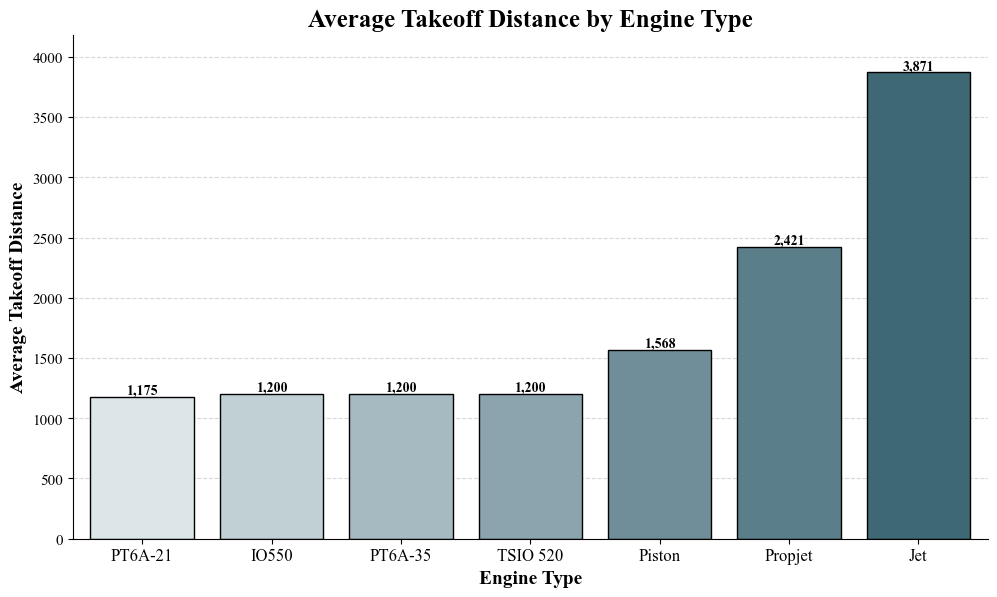

In [86]:
visual_5 = df.groupby("Engine Type")["Takeoff distance"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_5.index, visual_5.values,
              color=colors[:len(visual_5)], edgecolor="black")

ax.set_title("Average Takeoff Distance by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Takeoff Distance", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_5.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_5.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

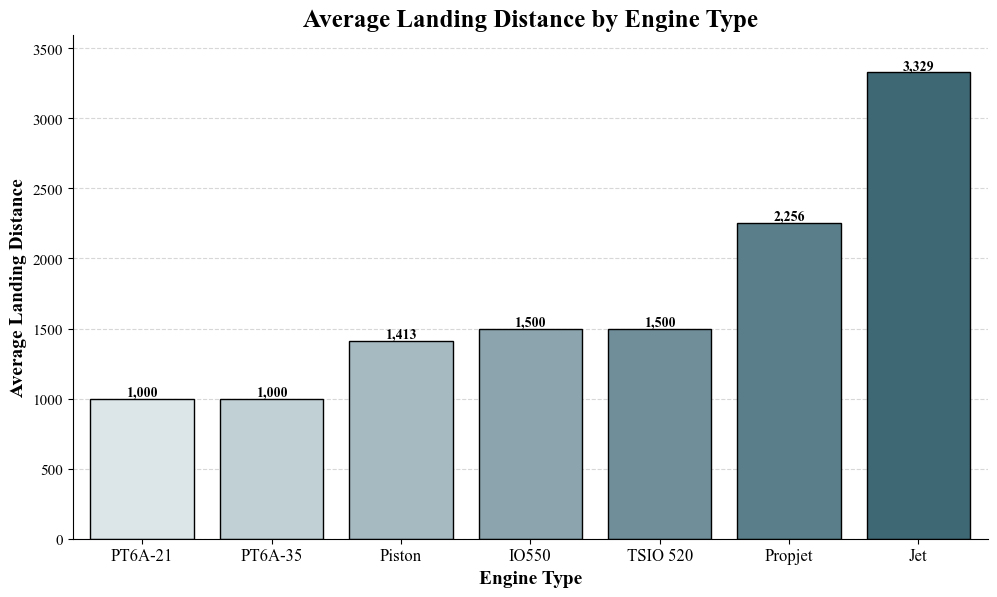

In [87]:
visual_6 = df.groupby("Engine Type")["Landing Distance"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_6.index, visual_6.values,
              color=colors[:len(visual_6)], edgecolor="black")

ax.set_title("Average Landing Distance by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Landing Distance", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_6.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_6.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

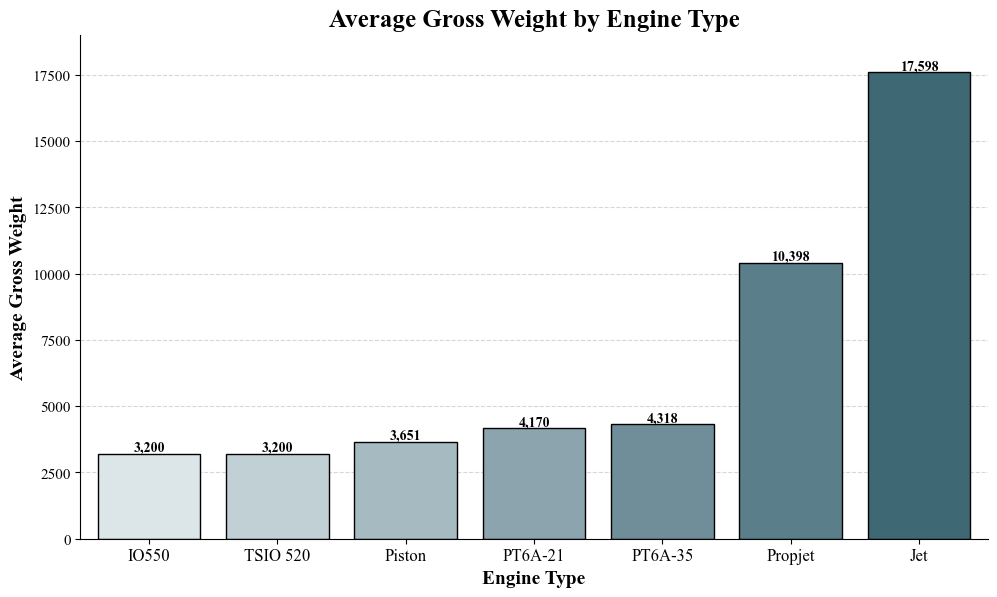

In [89]:
visual_7 = df.groupby("Engine Type")["Gross Weight"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_7.index, visual_7.values,
              color=colors[:len(visual_7)], edgecolor="black")

ax.set_title("Average Gross Weight by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Gross Weight", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_7.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_7.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

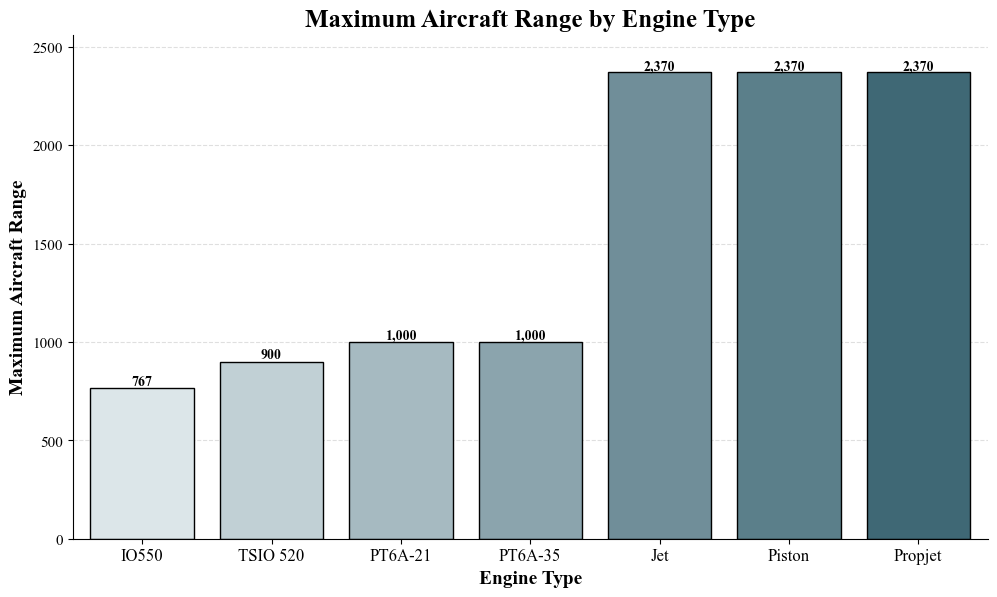

In [91]:
visual_8 = df.groupby("Engine Type")["Aircraft Range"].max().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(visual_8.index, visual_8.values,
              color=colors[:len(visual_8)], edgecolor="black")

ax.set_title("Maximum Aircraft Range by Engine Type",
             fontsize=18, fontweight="bold")
ax.set_xlabel("Engine Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Maximum Aircraft Range", fontsize=14, fontweight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, visual_8.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)
ax.set_ylim(0, visual_8.max() * 1.08)

plt.tight_layout(pad=0.8)
plt.show()

In [ ]:
SUMMARY:

This project analyzes aircraft performance using Python and Pandas. The dataset was cleaned and analyzed based on 
different engine types. Key performance parameters such as maximum speed, fuel capacity, service ceiling, takeoff and l
anding distance, gross weight, and aircraft range were compared using bar charts. The analysis provides a clear understanding 
of how aircraft performance characteristics vary across different engine types.
